# 03 — Feature Engineering
**CRISP-DM Phase 3: Data Preparation**

Builds all feature groups via the `src/churn/features/` modules, materialises
the feature matrix, and validates with Pandera. All heavy SQL runs inside DuckDB.

| Section | What it does |
|---------|-------------|
| 1. Feature Groups | Individual feature group shapes & previews |
| 2. Full Feature Matrix | Assembly with churn label & target encoding |
| 3. Null Analysis | Post-merge missingness from left joins |
| 4. Feature Distributions | Churn vs active distributions per feature |
| 5. Correlations & Multicollinearity | Target correlation + redundant feature pairs |
| 6. Leakage Verification | Functional temporal integrity checks |
| 7. Materialise | Save Parquet splits for modelling |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from churn.config import cfg
from churn.data.loader import ingest_raw_tables, get_connection
from churn.features.feature_store import build_feature_matrix, materialise_features
from churn.features.call_features import build_call_features
from churn.features.usage_features import build_usage_features
from churn.features.contract_features import build_contract_features

# ── Executive visual theme (consistent with 01_eda and 02_data_quality) ───────
%matplotlib inline
ACCENT   = '#1565C0'
PASS_CLR = '#388E3C'
FAIL_CLR = '#D32F2F'
WARN_CLR = '#F57C00'
NEUTRAL  = '#546E7A'
sns.set_theme(style='white')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 120})

ingest_raw_tables()
con = get_connection()
print('Data loaded.')

Data loaded.


## 1. Feature Groups

| Group | Source table | # Features | Method |
|-------|-------------|-----------|--------|
| Call centre | calls | 11 | DuckDB SQL aggregates + rolling windows |
| Usage | usage | 8 | DuckDB SQL aggregates + trends |
| Contract / account | customer_info | ~16 | Pandas transforms + one-hot encoding |
| Target-encoded | customer_info + cease | 2 | K-fold CV target encoding (smoothed) |

In [4]:
# Build individual feature groups for inspection
snapshot_date = cfg.splits.train_end_date

# ── Call features (DuckDB-side aggregation — snapshot-bounded) ────────────────
print('Building call features...')
call_feats = build_call_features(snapshot_date, con)
print(f'  Shape: {call_feats.shape}')
display(call_feats.head())

# ── Usage features (DuckDB-side with TRY_CAST for text → numeric) ────────────
print('\nBuilding usage features...')
usage_feats = build_usage_features(snapshot_date, con)
print(f'  Shape: {usage_feats.shape}')
display(usage_feats.head())

# ── Contract features (pre-snapshot customer_info only — prevents leakage) ────
print('\nBuilding contract features...')
ci_sql = f"""
    SELECT ci.*
    FROM customer_info ci
    INNER JOIN (
        SELECT unique_customer_identifier, MAX(datevalue) AS latest_date
        FROM customer_info
        WHERE datevalue <= DATE '{snapshot_date}'
        GROUP BY unique_customer_identifier
    ) latest USING (unique_customer_identifier)
    WHERE ci.datevalue = latest.latest_date
"""
cust_info = con.execute(ci_sql).fetchdf()
contract_feats = build_contract_features(cust_info, snapshot_date)
print(f'  Shape: {contract_feats.shape}')
display(contract_feats.head())

Building call features...
  Shape: (83367, 12)


,unique_customer_identifier,call_count_7d,call_count_14d,call_count_30d,call_count_90d,loyalty_call_flag_30d,loyalty_call_count_90d,pct_loyalty_calls_90d,avg_talk_time_30d,avg_hold_time_30d,days_since_last_call,call_frequency_trend
0,ab461b3ef5d353cf2afc5fb7a682b95768c6cb36a0a705...,0.0,0.0,0.0,0.0,0,0.0,0.000000,NaN,NaN,100,1.000000
1,160a6954cc288898f3b85b8fc4ab413cd1aed850c9498f...,0.0,0.0,0.0,1.0,0,0.0,0.000000,NaN,NaN,58,0.000000
2,8a15ae4f5c6c697441443ef6f20cf6ce3cf44cb12a45f7...,0.0,1.0,10.0,46.0,0,9.0,0.195652,555.4,286.1,14,0.652174
3,8beac0d182cc1a4e10f97ce232ecc2c61fbf5b0aaa27ed...,0.0,0.0,0.0,1.0,0,1.0,1.000000,NaN,NaN,61,0.000000
4,03a33a148a42582f9bb2d8fcf82633eb27acf3d1ec4942...,2.0,2.0,2.0,5.0,0,2.0,0.400000,258.0,174.5,5,1.200000



Building usage features...
  Shape: (182593, 9)


,unique_customer_identifier,avg_download_30d,avg_upload_30d,avg_download_7d,download_trend_7_30,download_pct_change_30_60d,zero_usage_days_30d,usage_volatility_30d,avg_daily_total_mb_30d
0,d03550f4797142c2fe145fcbeb7ec247b7771b5153605d...,20627.852533,517.791400,22117.141429,1.072198,-0.201119,0.0,3574.702112,21145.643933
1,1ac8215f9e98d15b235e6baa5b4a45dafa930201348b23...,NaN,NaN,NaN,1.000000,0.000000,0.0,NaN,NaN
2,17f6b51c5295d23443a9e0736dd2209b76aba82cbef303...,8083.644233,262.361500,6817.116571,0.843322,-0.507594,0.0,5947.973547,8346.005733
3,28305b0142631079c8b2fa51149867a143de44b9f303e9...,4496.644700,193.113133,4125.120571,0.917377,-0.432040,0.0,3703.994467,4689.757833
4,0ea9eddd944adcda453338e543c36eb7a41ca203723d50...,3109.427767,239.946000,3459.425571,1.112560,0.012630,0.0,3271.225128,3349.373767



Building contract features...
  Shape: (198742, 20)


,unique_customer_identifier,ooc_days,is_out_of_contract,days_to_ooc,contract_status_risk,speed_gap,speed_gap_pct,dd_cancel_60_day,has_dd_cancel,dd_cancel_log,contract_dd_cancels,tenure_days,tenure_log,tenure_bucket,sales_channel,crm_package_name,tech_FTTC,tech_FTTP,tech_GFAST,tech_MPF
0,19a86c9ecf4c01b9d115c0b053b02902f388baafe12f77...,-672.0,0,672.0,0,0.000000,0.000000,0,0,0.000000,0,1878,7.538495,3yr+,Retail,Fibre 35 (FTTC-OR),1,0,0,0
1,a94970407bb270cd965713f95cc52da34d8df0cfdfa4f5...,161.0,1,0.0,5,30.123445,0.463438,0,0,0.000000,0,1101,7.004882,3yr+,Online - Search,Fibre 65 (FTTC-OR),1,0,0,0
2,72bcca27d63af55626d51deb746358ad5f2d6f40176833...,-154.0,0,154.0,1,1.705000,0.026231,0,0,0.000000,0,394,5.978886,1-3yr,Online - Affiliate,Fibre 65 (FTTC-OR),1,0,0,0
3,278df56b30864348edf82b55abeead1868cd3f64ac010c...,297.0,1,0.0,5,18.398000,0.283046,1,1,0.693147,1,2048,7.625107,3yr+,Inbound,Fibre 65 (FTTC-OR),1,0,0,0
4,df361b802ec18bb7c0aa7c78a62230111d1657efe120bc...,-162.0,0,162.0,1,0.000000,0.000000,0,0,0.000000,0,386,5.958425,1-3yr,Online - Affiliate,Fibre 65 (FTTC-OR),1,0,0,0


## 2. Full Feature Matrix

In [5]:
# Build full feature matrix with churn label + target encoding
# build_feature_matrix returns (DataFrame, fitted_target_encoder)
feature_matrix, target_encoder = build_feature_matrix(snapshot_date, con)

print(f'Feature matrix: {feature_matrix.shape}')
print(f'Churn rate: {feature_matrix["churned"].mean():.2%}')
print(f'Target-encoded columns: {[c for c in feature_matrix.columns if "_encoded" in c]}')
display(feature_matrix.describe().T)

Feature matrix: (198742, 43)
Churn rate: 8.65%
Target-encoded columns: ['crm_package_name_encoded', 'sales_channel_encoded']


,count,mean,min,25%,50%,75%,max,std
ooc_days,197820.0,88.815009,-729.0,-306.0,-75.0,105.0,7364.0,808.094351
is_out_of_contract,198742.0,0.344844,0.0,0.0,0.0,1.0,1.0,0.475319
days_to_ooc,197820.0,164.069781,-0.0,0.0,75.0,306.0,729.0,193.361242
contract_status_risk,198742.0,2.485303,0.0,1.0,2.0,5.0,5.0,1.806459
speed_gap,198742.0,16.247865,0.0,0.0,2.766078,19.932277,1000.0,49.203178
speed_gap_pct,198742.0,0.300682,0.0,0.0,0.060548,0.543292,1.0,0.392793
dd_cancel_60_day,198742.0,0.090806,0.0,0.0,0.0,0.0,1.0,0.287334
has_dd_cancel,198742.0,0.090806,0.0,0.0,0.0,0.0,1.0,0.287334
dd_cancel_log,198742.0,0.062942,0.0,0.0,0.0,0.0,0.693147,0.199165
contract_dd_cancels,198742.0,0.136851,0.0,0.0,0.0,0.0,1.0,0.343691


## 3. Null Analysis
Call and usage features are **left-joined** — customers with no call or usage
history will have NaN for all those columns. This section quantifies
missingness and documents the imputation strategy for modelling.

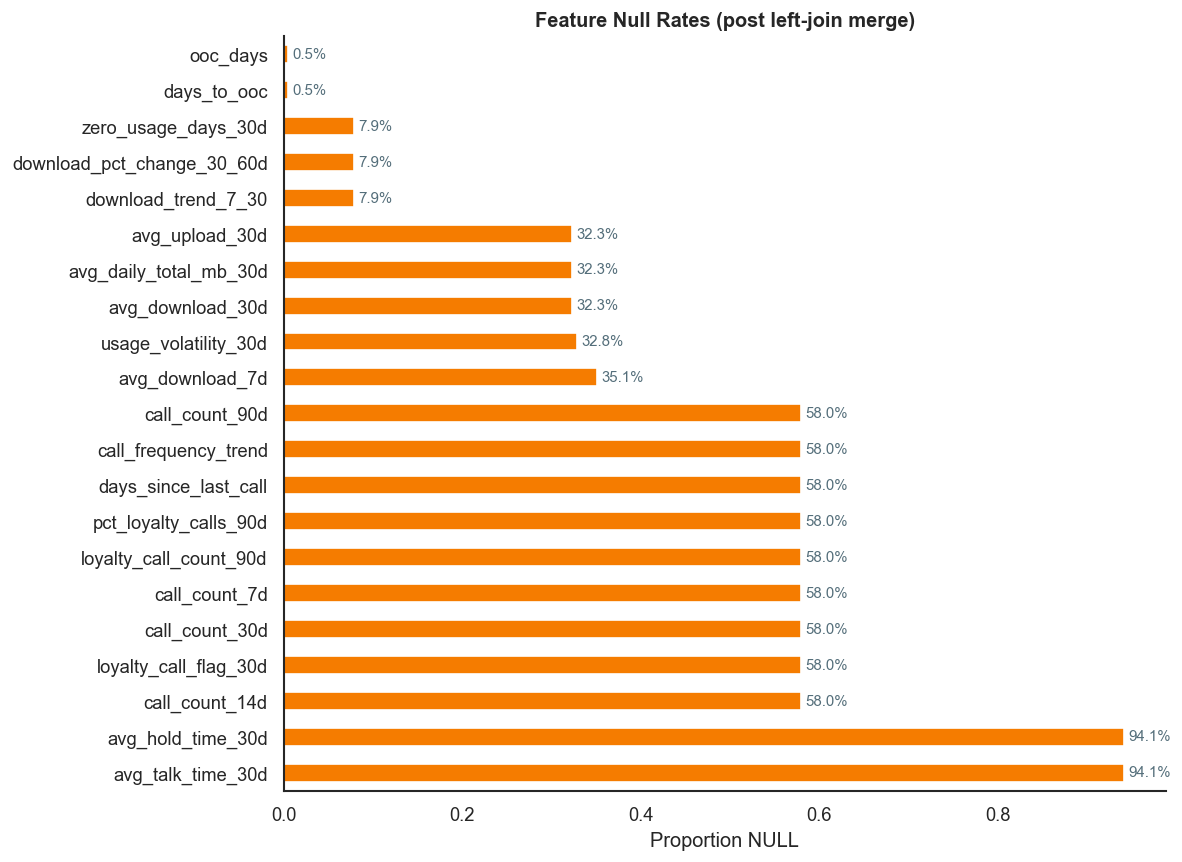

Customers with no call history:  115,209 (58.0%)
Customers with no usage history: 15,676 (7.9%)

→ Strategy: LightGBM handles NaN natively (routes to optimal split).
  No imputation needed — NaN is informative (customer absence = churn signal).


In [6]:
# Null rates after left-join merge
null_rates = feature_matrix.isnull().mean().sort_values(ascending=False)
has_nulls = null_rates[null_rates > 0]

if len(has_nulls) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(has_nulls) * 0.35)))
    has_nulls.plot(kind='barh', color=WARN_CLR, edgecolor='white', ax=ax)
    ax.set_title('Feature Null Rates (post left-join merge)', fontweight='bold')
    ax.set_xlabel('Proportion NULL')
    for bar in ax.patches:
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.1%}', va='center', fontsize=9, color=NEUTRAL)
    sns.despine()
    plt.tight_layout()
    plt.show()

    # Breakdown by source
    call_cols = [c for c in feature_matrix.columns
                 if c in call_feats.columns and c != 'unique_customer_identifier']
    usage_cols = [c for c in feature_matrix.columns
                  if c in usage_feats.columns and c != 'unique_customer_identifier']
    n_no_calls = feature_matrix[call_cols].isnull().all(axis=1).sum() if call_cols else 0
    n_no_usage = feature_matrix[usage_cols].isnull().all(axis=1).sum() if usage_cols else 0
    print(f'Customers with no call history:  {n_no_calls:,} ({n_no_calls/len(feature_matrix):.1%})')
    print(f'Customers with no usage history: {n_no_usage:,} ({n_no_usage/len(feature_matrix):.1%})')
    print(f'\n→ Strategy: LightGBM handles NaN natively (routes to optimal split).')
    print(f'  No imputation needed — NaN is informative (customer absence = churn signal).')
else:
    print('✓ No null values in the feature matrix.')

## 4. Feature Distributions

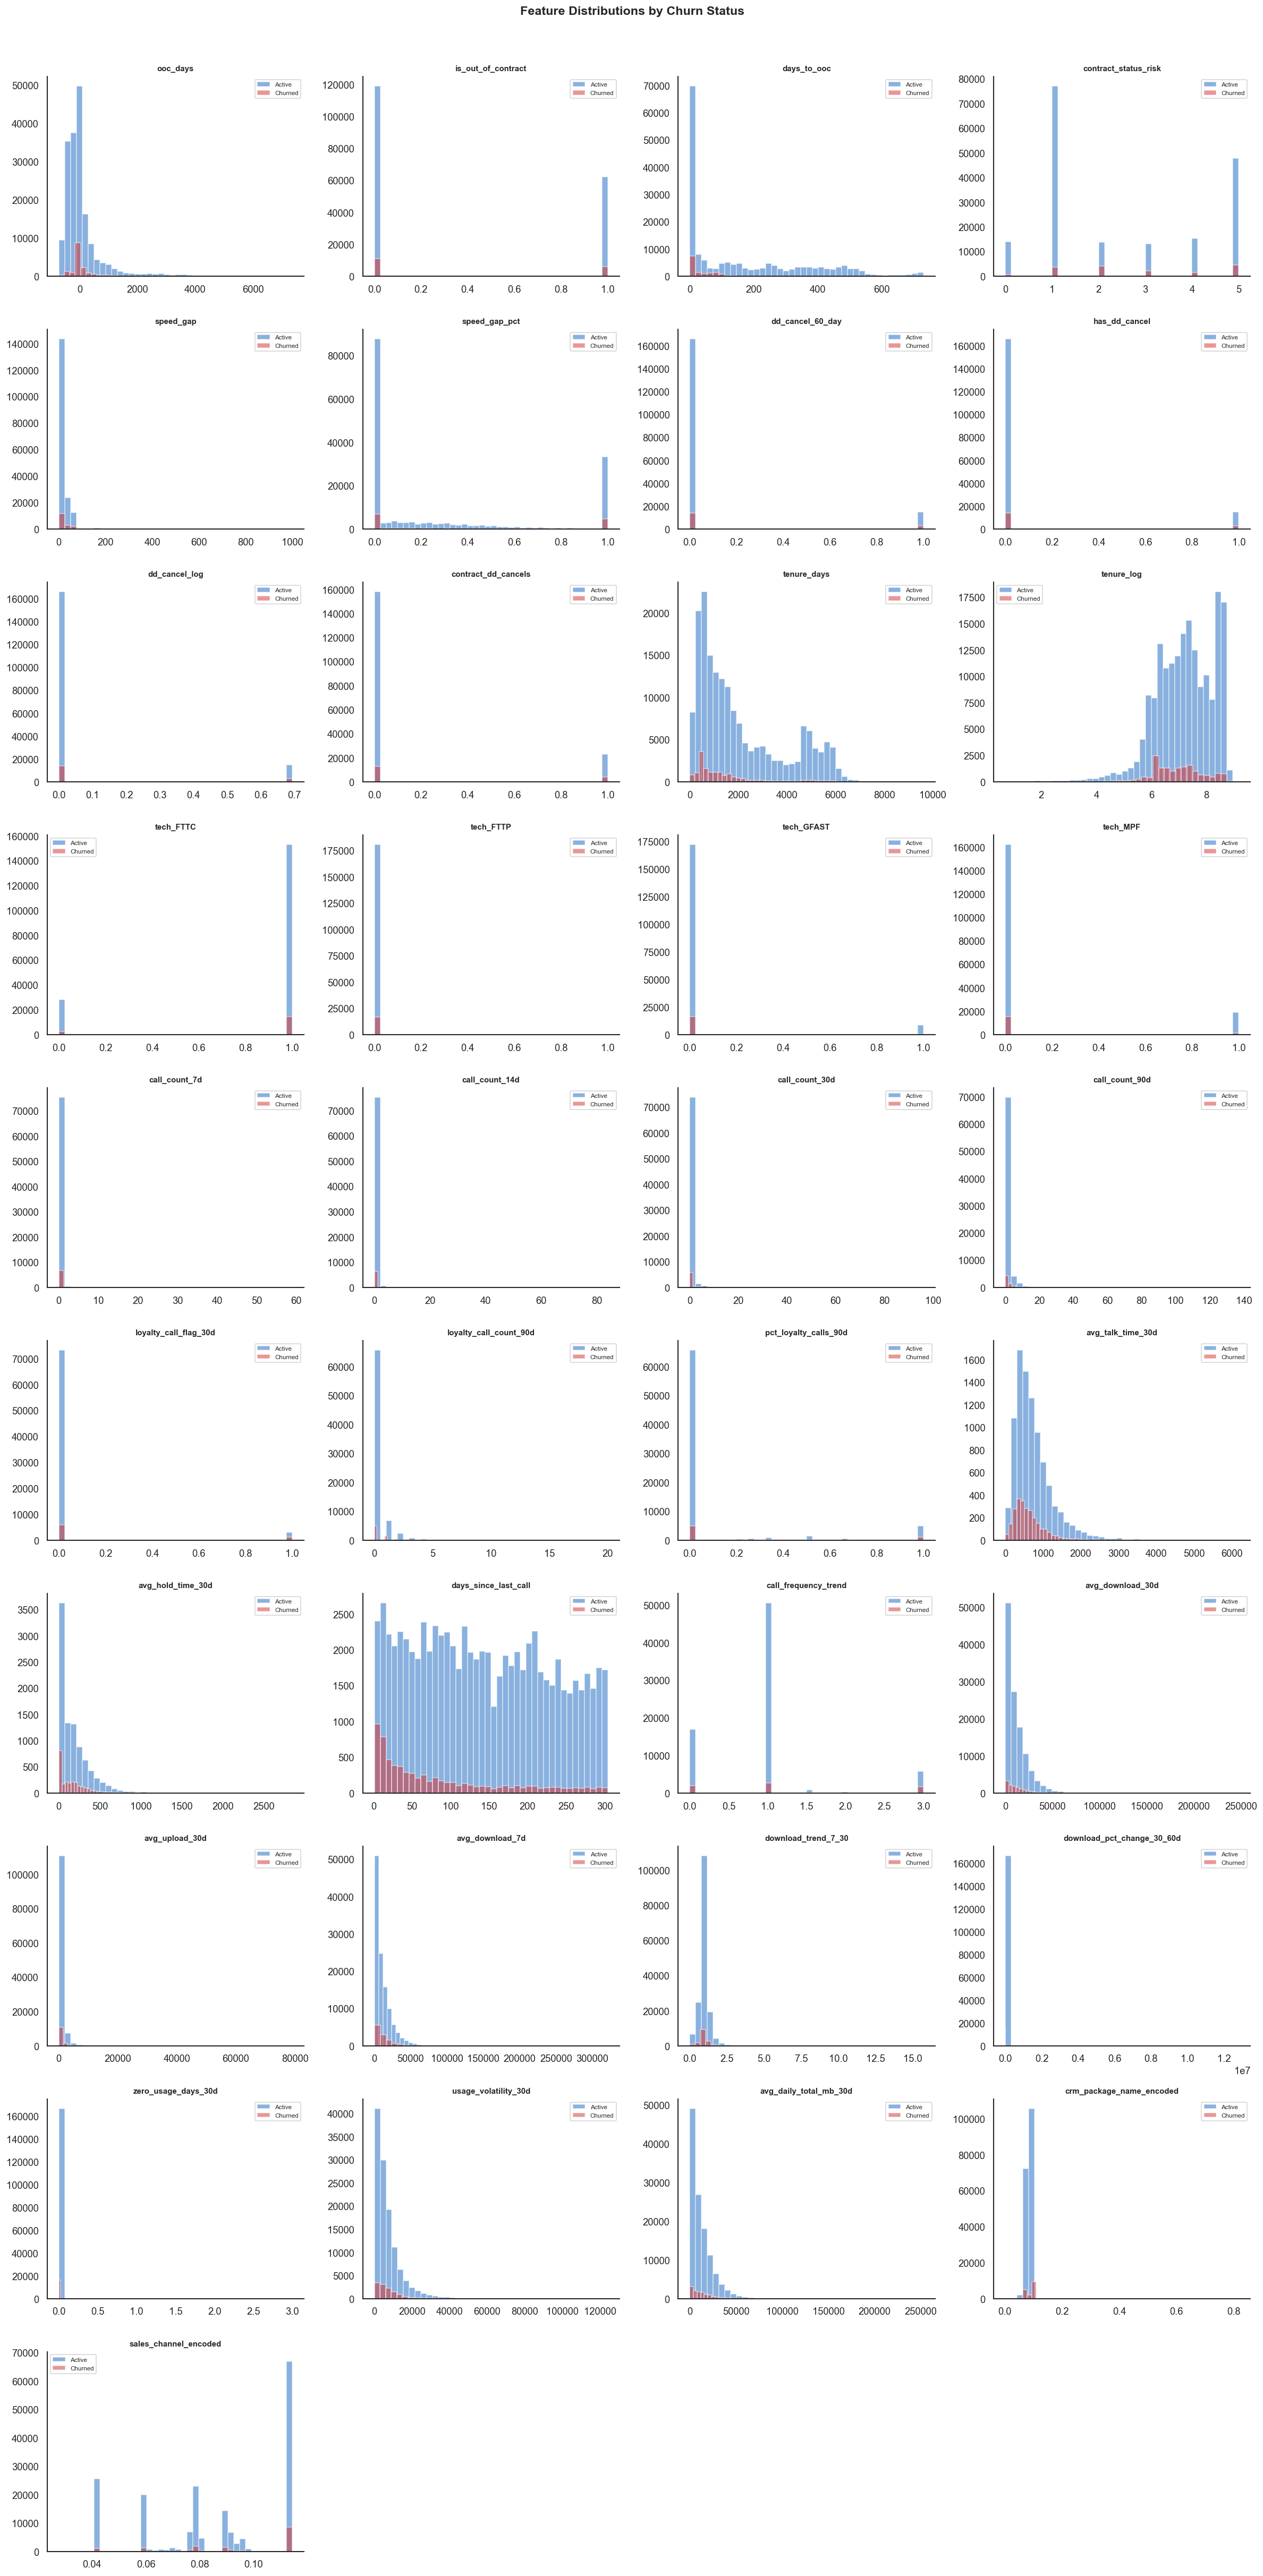

In [7]:
# Plot distributions of numeric features coloured by churn
num_cols = feature_matrix.select_dtypes(include='number').columns.drop(
    ['churned'], errors='ignore')

n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color, name in [(0, ACCENT, 'Active'), (1, FAIL_CLR, 'Churned')]:
        subset = feature_matrix[feature_matrix['churned'] == label][col].dropna()
        axes[i].hist(subset, bins=40, alpha=0.5, color=color, label=name)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
    sns.despine(ax=axes[i])

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Churn Status', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Correlations & Multicollinearity
Target correlation identifies the strongest predictive features.
Multicollinearity check flags redundant feature pairs that can destabilise
linear models and inflate SHAP explanations.

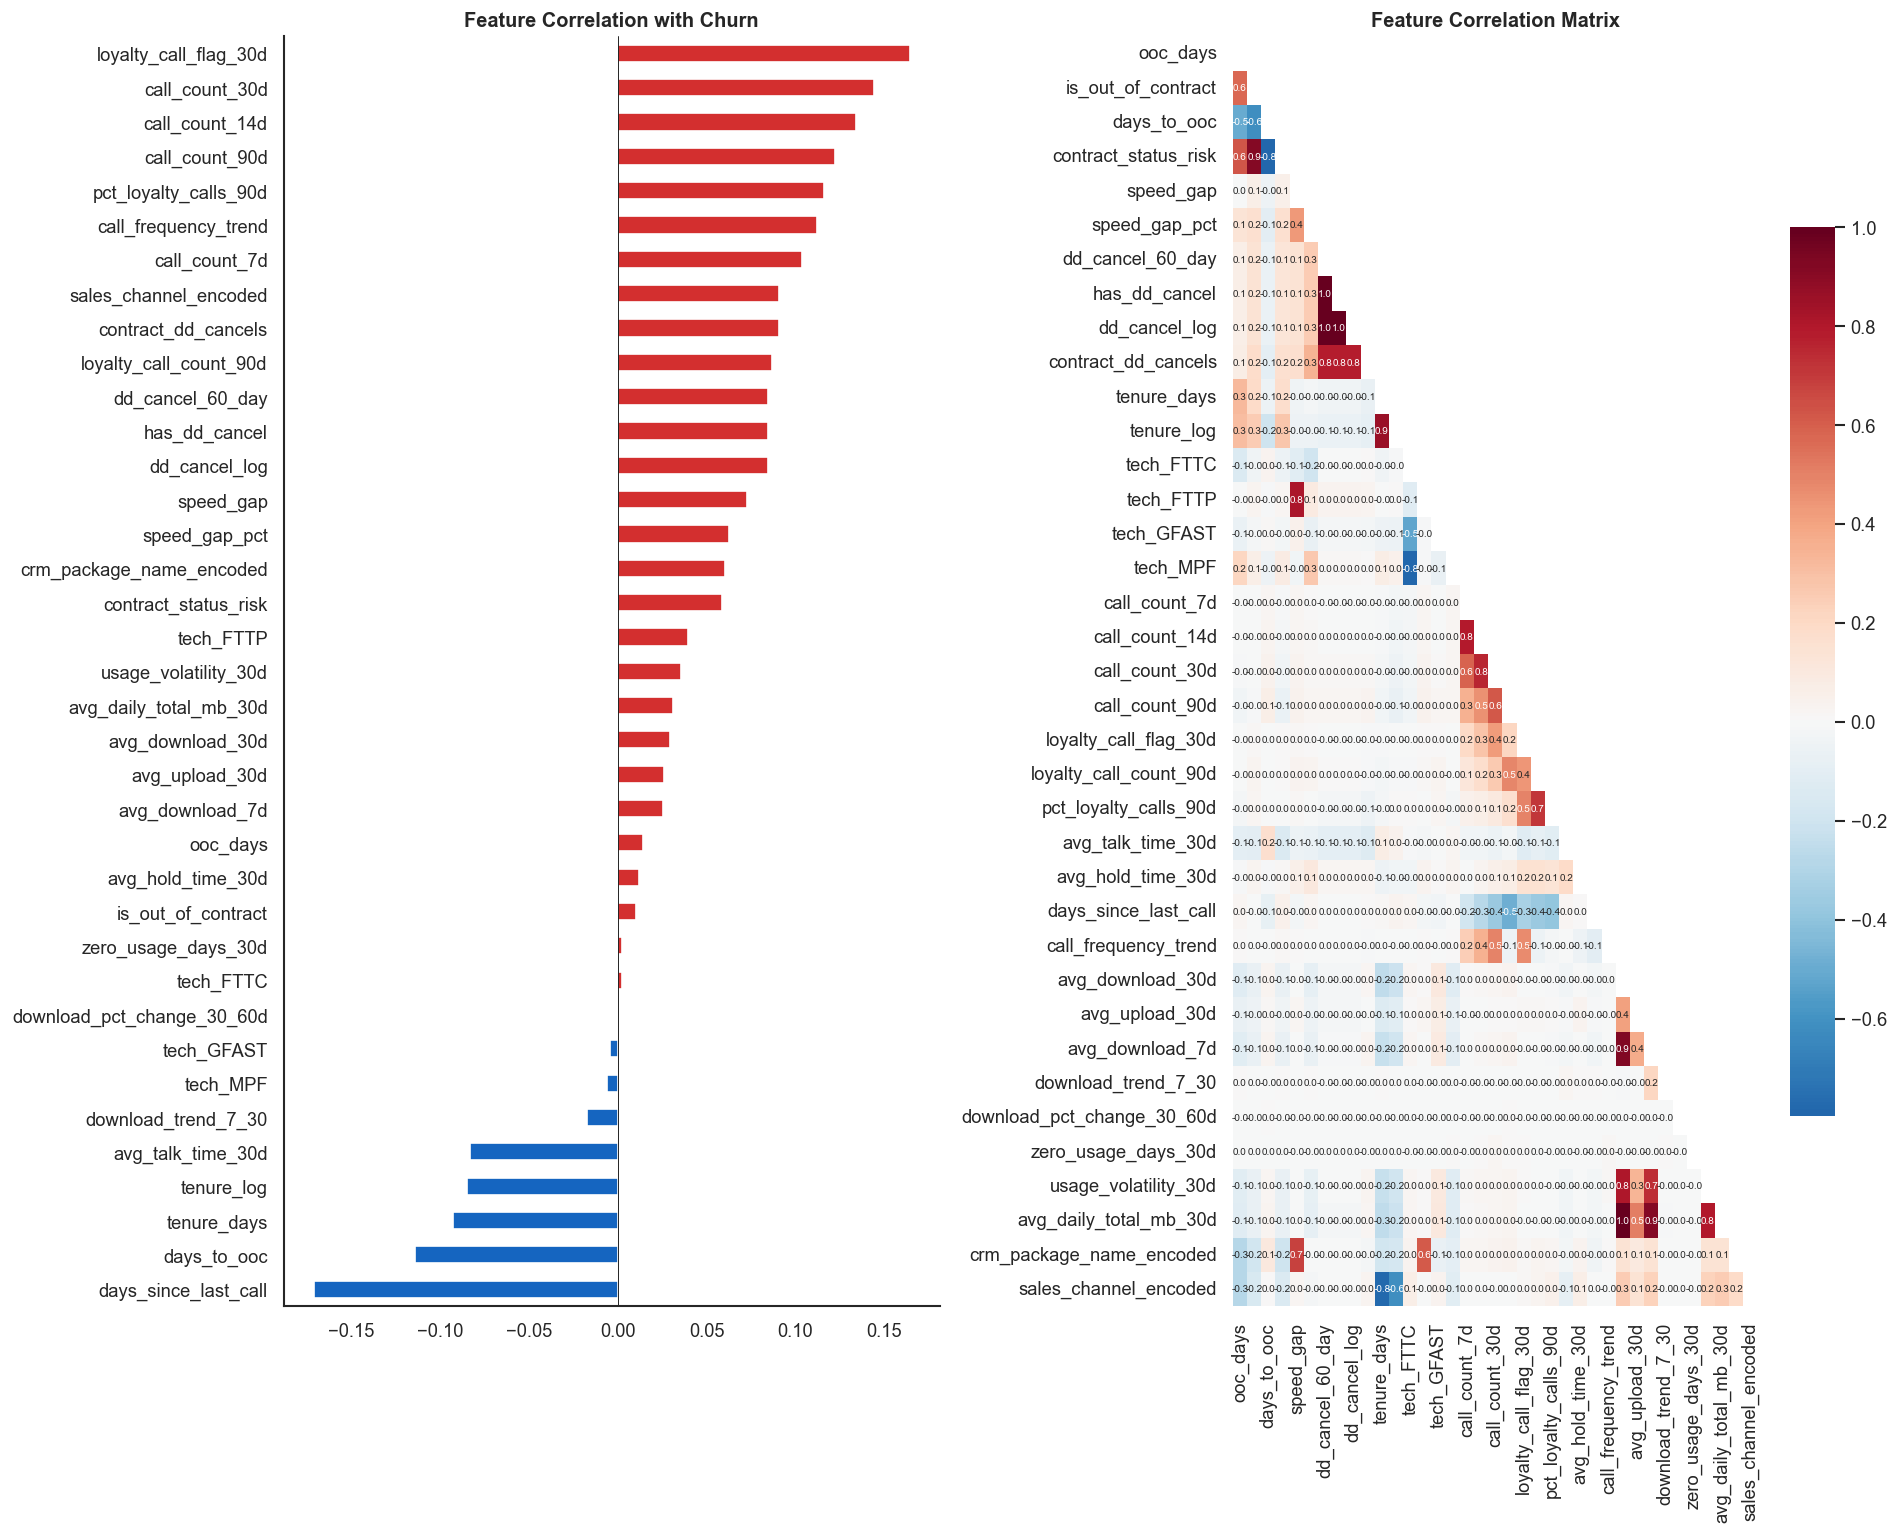


── Multicollinearity Check (|r| > 0.85) ──
  ⚠ dd_cancel_log ↔ dd_cancel_60_day:  r = 1.000
  ⚠ dd_cancel_log ↔ has_dd_cancel:  r = 1.000
  ⚠ has_dd_cancel ↔ dd_cancel_60_day:  r = 1.000
  ⚠ avg_daily_total_mb_30d ↔ avg_download_30d:  r = 0.993
  ⚠ avg_download_7d ↔ avg_download_30d:  r = 0.919
  ⚠ avg_daily_total_mb_30d ↔ avg_download_7d:  r = 0.912
  ⚠ contract_status_risk ↔ is_out_of_contract:  r = 0.910
  ⚠ tenure_log ↔ tenure_days:  r = 0.866

  → 8 pair(s) above threshold.
    LightGBM is tree-based and tolerates collinearity, but consider
    dropping one from each pair for cleaner SHAP interpretability.


In [8]:
# Correlation with target
target_corr = feature_matrix[num_cols].corrwith(feature_matrix['churned']).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, max(8, len(num_cols) * 0.35)))

# Bar chart of target correlations
target_corr.plot(kind='barh', ax=axes[0], color=target_corr.apply(
    lambda x: FAIL_CLR if x > 0 else ACCENT))
axes[0].set_title('Feature Correlation with Churn', fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.5)
sns.despine(ax=axes[0])

# Full correlation heatmap
corr_matrix = feature_matrix[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, annot=True,
            ax=axes[1], cbar_kws={'shrink': 0.7}, fmt='.1f', annot_kws={'size': 6})
axes[1].set_title('Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

# ── Multicollinearity check: flag highly correlated feature pairs ─────────────
print('\n── Multicollinearity Check (|r| > 0.85) ──')
upper = corr_matrix.where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1))
high_corr = [(col, row, corr_matrix.loc[row, col])
             for col in upper.columns for row in upper.index
             if pd.notna(upper.loc[row, col]) and abs(upper.loc[row, col]) > 0.85]

if high_corr:
    for c1, c2, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f'  ⚠ {c1} ↔ {c2}:  r = {r:.3f}')
    print(f'\n  → {len(high_corr)} pair(s) above threshold.')
    print(f'    LightGBM is tree-based and tolerates collinearity, but consider')
    print(f'    dropping one from each pair for cleaner SHAP interpretability.')
else:
    print('  ✓ No feature pairs exceed |r| > 0.85')

## 6. Leakage Verification
Functional checks confirming that no feature uses data from after `snapshot_date`.
Repeats the checks from 02_data_quality but applied to the materialised feature matrix.

In [9]:
# ── CHECK 1: No cease-related columns leaked into features ────────────────────
leakage_cols = ['cease_placed_date', 'cease_completed_date',
                'reason_description', 'reason_description_insight']
leaked = [c for c in leakage_cols if c in feature_matrix.columns]
print('CHECK 1 — No cease columns in feature matrix:')
if leaked:
    print(f'  ✗ LEAKED: {leaked}')
else:
    print(f'  ✓ All cease columns absent from features')

# ── CHECK 2: snapshot_date is consistent ──────────────────────────────────────
snap_vals = feature_matrix['snapshot_date'].unique()
print(f'\nCHECK 2 — Snapshot date consistency:')
print(f'  Unique snapshot dates: {snap_vals}')
assert len(snap_vals) == 1, 'Multiple snapshot dates in single matrix!'
print(f'  ✓ Single snapshot date: {snap_vals[0]}')

# ── CHECK 3: Label window sanity ─────────────────────────────────────────────
window = cfg.label.prediction_window_days
churn_rate = feature_matrix['churned'].mean()
n_churned = feature_matrix['churned'].sum()
print(f'\nCHECK 3 — Label window = {window} days from {snapshot_date}:')
print(f'  Churned: {n_churned:,.0f} / {len(feature_matrix):,} = {churn_rate:.2%}')
print(f'  ✓ Labels computed from cease_placed_date ∈ [{snapshot_date}, +{window}d)')

# ── CHECK 4: Feature temporal bounds confirmed by source ──────────────────────
print(f'\nCHECK 4 — Feature temporal bounds (enforced in source SQL):')
print(f'  ✓ call_features:     WHERE event_date < DATE \'{snapshot_date}\'')
print(f'  ✓ usage_features:    WHERE calendar_date < DATE \'{snapshot_date}\'')
print(f'  ✓ contract_features: WHERE datevalue <= DATE \'{snapshot_date}\' (most recent pre-snapshot)')
print(f'  All three feature modules enforce strict pre-snapshot boundaries.')

CHECK 1 — No cease columns in feature matrix:
  ✓ All cease columns absent from features

CHECK 2 — Snapshot date consistency:
  Unique snapshot dates: <DatetimeArray>
['2023-06-01 00:00:00']
Length: 1, dtype: datetime64[s]
  ✓ Single snapshot date: 2023-06-01 00:00:00

CHECK 3 — Label window = 90 days from 2023-06-01:
  Churned: 17,192 / 198,742 = 8.65%
  ✓ Labels computed from cease_placed_date ∈ [2023-06-01, +90d)

CHECK 4 — Feature temporal bounds (enforced in source SQL):
  ✓ call_features:     WHERE event_date < DATE '2023-06-01'
  ✓ usage_features:    WHERE calendar_date < DATE '2023-06-01'
  ✓ contract_features: WHERE datevalue <= DATE '2023-06-01' (most recent pre-snapshot)
  All three feature modules enforce strict pre-snapshot boundaries.


## 7. Materialise Features

In [10]:
# Save feature matrices for all temporal splits
snapshot_dates = [
    cfg.splits.train_end_date,
    cfg.splits.val_end_date,
    cfg.splits.test_end_date,
]
materialise_features(snapshot_dates, con=con)
print('Feature matrices saved to:', cfg.paths.features_dir)

# Verify output files
for snap in snapshot_dates:
    path = cfg.paths.features_dir / f'features_{snap}.parquet'
    size_mb = os.path.getsize(path) / 1e6
    df_check = pd.read_parquet(path)
    print(f'  {path.name}: {df_check.shape[0]:,} rows × {df_check.shape[1]} cols ({size_mb:.1f} MB)')

Feature matrices saved to: /Users/victoroko/Documents/tech-test/data/features
  features_2023-06-01.parquet: 198,742 rows × 43 cols (26.9 MB)
  features_2023-08-01.parquet: 199,951 rows × 43 cols (26.5 MB)
  features_2023-10-01.parquet: 200,806 rows × 43 cols (26.1 MB)
